In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from scipy.integrate import trapezoid

import sys
sys.path.append("../")
from src.preprocessing import weigh_norm_densities, align_densities, df_to_densities, fit_kde_model, align_and_normalize_density
from src.transformations import ( 
                            mLQDT,
                            obtain_densities_from_lqd,
                            dens2lqd,
                            lqd2dens,
                            compute_lqd_cut
                            )
                            

In [2]:
lqd_plots_xaxis = [-0.05, 1.05]

# Normal

In [3]:
# SIMULATION
mu = 0
sigma = 2
n = 5001
normal_sample = np.random.normal(loc=mu, scale=sigma, size=n)
grid = np.linspace(normal_sample.min(), normal_sample.max(), n)

# KDE
params = {'kernel': 'gaussian', 'bandwidth': 'scott'}
kde, density = fit_kde_model(normal_sample, params)

# PLOT KDE
fig = px.line(x=kde.grid, y=density, title="KDE")
fig.show()

In [4]:
# mLQDT
lqd_grid = np.linspace(0,1,n)
t0_ = kde.grid[np.argmin(np.abs(kde.grid))]
lqdSup, lqd, c = dens2lqd(
                        dens = density,
                        dSup = grid,
                        lqdSup = lqd_grid,
                        t0=t0_
                )

# VISUALIZE mLQDT
fig = px.line(x=lqdSup, y=lqd, title="LQD")
fig.update_xaxes(range=lqd_plots_xaxis)
fig.show()

Density does not integrate to 1 with tolerance 1e-5 - renormalizing now.


In [5]:
# BACKWARDS TRANSFORMATION
dSup, dens = lqd2dens(lqd, lqdSup, c=c, dSup=kde.grid)
fig = go.Figure()

# COMPARE KDE AND mLQDT INVERSE
fig.add_trace(
    go.Scatter(
        x=kde.grid,
        y=density,
        mode="lines",
        name="custom kde",
        line=dict(color="black")
    )
)

fig.add_trace(
    go.Scatter(
        x=dSup,
        y=dens,
        mode="lines",
        name="backwards custom kde",
        line=dict(color="red")
    )
)

fig.show()

c not in lqdSup — resetting to closest value.


# Empiral density

In [6]:
# DATA
data_path = "../data/processed/"
returns_path = ''.join([data_path, 'ibovespa_treated.xlsx'])
df = pd.read_excel(returns_path, index_col="time")
df.head()

,2024-12-02,2024-12-03,2024-12-04,2024-12-05,2024-12-06,2024-12-09,2024-12-10,2024-12-11,2024-12-12,2024-12-13,...,2025-11-14,2025-11-17,2025-11-18,2025-11-19,2025-11-21,2025-11-24,2025-11-25,2025-11-26,2025-11-27,2025-11-28
time,,,,,,,,,,,,,,,,,,,,,
10:00:00,0.000011,-0.000372,-0.000035,0.007233,-0.001305,-0.000459,0.002388,0.002212,-0.008001,-0.000824,...,-0.000957,-0.002307,-0.003734,-0.005020,-0.001139,-0.000255,0.002339,0.004176,-0.000224,-0.000238
10:05:00,-0.002271,0.003372,0.001716,0.005538,0.000069,0.006429,0.002343,0.001918,-0.007582,-0.000413,...,-0.001522,0.000739,-0.000613,0.000306,-0.002021,-0.000810,0.001557,-0.001565,-0.000193,0.002906
10:10:00,-0.000582,0.002832,-0.000502,0.000739,0.000261,0.001891,0.000775,-0.001172,0.000216,-0.000432,...,0.000360,-0.000105,-0.000159,-0.000362,0.000092,0.001131,0.001170,0.000202,0.000556,0.000475
10:15:00,-0.001997,0.001091,0.000111,-0.000192,0.000407,-0.001392,-0.000477,-0.001526,0.000198,-0.001821,...,0.001121,-0.000284,0.003272,-0.001107,-0.001012,-0.000174,0.001002,0.001815,-0.000168,0.000973
10:20:00,-0.000037,-0.000505,-0.000327,-0.000580,-0.000436,-0.000405,0.001263,0.000676,-0.002667,0.001033,...,0.000449,0.000335,0.000853,0.000981,-0.000057,-0.000096,0.000832,0.001951,0.001060,-0.001004


In [7]:
# CURVE SELECTION
i = 10
t = df.columns[i]
Z_t = df.loc[:, t]

# KDE PARAMETERS
n = 5001
params = {"kernel": "t_student", "bandwidth": "scott", "df": 2, "adaptive": True}
# params = {'kernel': 't_student', "df": 2, 'bandwidth': 'scott'}
# params = {'kernel': 'gaussian', 'bandwidth': 'scott'}
grid = np.linspace(df.min().min(), df.max().max(), n)

In [8]:
# KDE ESTIMATION
kde, density = fit_kde_model(Z_t, params, grid=grid)
# print("KDE Integral: ", trapezoid(density/trapezoid(density, kde.grid), kde.grid))

# KDE VISUALIZATION
fig = px.line(x=grid, y=density, title="KDE")
fig.show()

In [9]:
# mLQDT
lqd_grid = np.linspace(0,1,n)
t0_ = grid[np.argmin(np.abs(grid))]
lqdSup, lqd, c = dens2lqd(
                        dens = density,
                        dSup = grid,
                        lqdSup = lqd_grid,
                        t0=t0_
                )

# mLQDT VISUALIZATION
fig = px.line(x=lqdSup, y=lqd, title="KDE")
fig.update_xaxes(range=lqd_plots_xaxis)
fig.show()

Density does not integrate to 1 with tolerance 1e-5 - renormalizing now.


In [26]:
# BACKWARDS TRANSFORMATION
dSup, dens = lqd2dens(
                lqd, 
                lqdSup, 
                c=c, 
                t0=t0_,
                # cut=(1,1),
                dSup=grid)

# COMPARE KDE AND BACKWARDS TRANSFORMATION
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=grid,
        y=density,
        mode="lines",
        name="custom kde",
        line=dict(color="black")
    )
)

fig.add_trace(
    go.Scatter(
        x=dSup,
        y=dens,
        mode="lines",
        name="backwards custom kde",
        line=dict(color="red")
    )
)

fig.show()

c not in lqdSup — resetting to closest value.


/Users/vizzotto/Documents/GitHub/densities4risk/notebooks/../src/transformations.py:541: IntegrationWarning:

The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.



The above result seems to be influenced by the 'cut' parameter from the lqd2dens function. Without it, the mLQDT curve matches the KDE perfectly. <br>
Parameters for the density so its mLQDT doesnt explode: {'kernel': 't_student', "df": 2, 'bandwidth': 'scott'}

# Resultados no R

## Versão no R - DJI_returns

In [12]:
df_r = pd.read_excel("../data/processed/r_transformation.xlsx")
df_r.sample(10)

,u,original_dens,backwards_dens
2580,-0.518013,0.000000e+00,0.000000
3194,-0.230455,7.945386e-04,0.000000
2167,-0.711436,1.539594e-17,0.000000
3316,-0.173318,3.230660e-01,0.323735
4443,0.354497,0.000000e+00,0.000000
660,-1.417218,1.124582e-16,0.000000
339,-1.567554,0.000000e+00,0.000000
587,-1.451407,7.587192e-17,0.000000
1942,-0.816811,7.368763e-17,0.000000
819,-1.342753,1.356149e-17,0.000000


In [13]:
fig = go.Figure()

# Gaussian KDE
fig.add_trace(
    go.Scatter(
        x=df_r.u,
        y=df_r.original_dens,
        mode="lines",
        name="custom kde",
        line=dict(color="black")
    )
)

# Gaussian KDE
fig.add_trace(
    go.Scatter(
        x=df_r.u,
        y=df_r.backwards_dens,
        mode="lines",
        name="backwards custom kde",
        line=dict(color="red")
    )
)


fig.show()

## Versão no R - Bovespa

In [14]:
i = 10
t = df.columns[i]
df_for_r = pd.DataFrame({'u': kde.grid, 'density': density})
df_for_r.to_excel("../data/interim/df_for_r.xlsx", index=False)

In [15]:
df_from_r = pd.read_excel(("../data/processed/r_transformation_bovespa_t.xlsx"))

In [16]:
fig = go.Figure()

# Gaussian KDE
fig.add_trace(
    go.Scatter(
        x=df_from_r.u,
        y=df_from_r.density,
        mode="lines",
        name="custom kde",
        line=dict(color="black")
    )
)

# Gaussian KDE
fig.add_trace(
    go.Scatter(
        x=df_from_r.u,
        y=df_from_r.backwards_density,
        mode="lines",
        name="backwards custom kde",
        line=dict(color="red")
    )
)


fig.show()

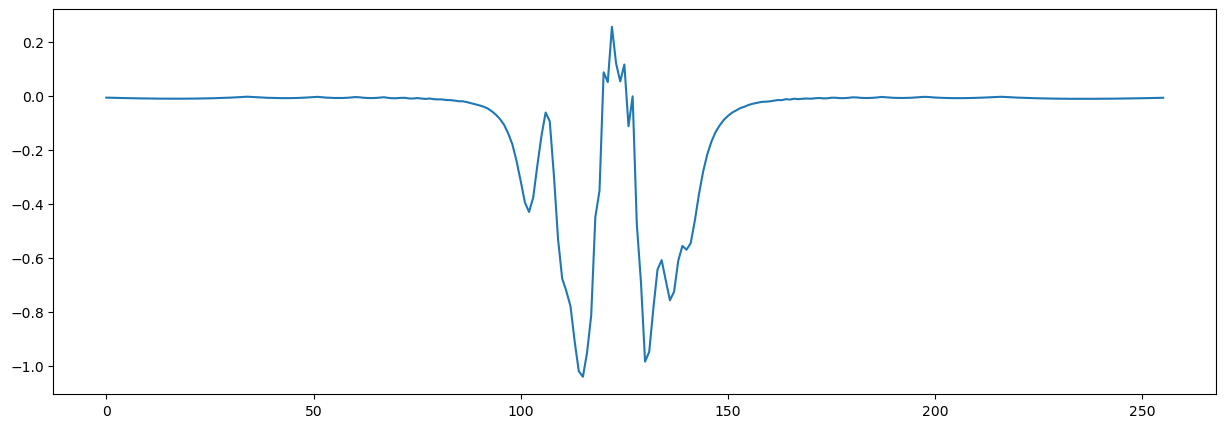

In [17]:
plt.figure(figsize=(15,5))

plt.plot(df_from_r.density - df_from_r.backwards_density)

plt.show()

# Adjusting LQDensity

In [18]:
# Dados
data_path = "../data/processed/"
returns_path = ''.join([data_path, 'ibovespa_treated.xlsx'])
df = pd.read_excel(returns_path, index_col="time")

n = 5001
grid = np.linspace(df.min().min(), df.max().max(), n)

i = 10
t = df.columns[i]

Z_t = df.loc[:, t]
# params = {'kernel': 't_student', "df": 2, 'bandwidth': 'scott'}
# params = {'kernel': 'gaussian', 'bandwidth': 'scott'}
params = {'kernel': 'epanechnikov', 'bandwidth': 'silverman', 'adaptive': True}
kde, density = fit_kde_model(Z_t, params, grid=grid)

fig = px.line(x=grid, y=density, title="KDE")
fig.show()

In [19]:
lqd_grid = np.linspace(0,1,5001)
t0_ = grid[np.argmin(np.abs(grid))]
lqdSup, lqd, c = dens2lqd(
                        dens = density,
                        dSup = grid,
                        lqdSup = lqd_grid,
                        t0=t0_
                )

fig = px.line(x=lqdSup, y=lqd, title="LQD")
fig.update_xaxes(range=lqd_plots_xaxis)
fig.show()

There are some zero density values - truncating support grid so all are positive


In [20]:
cut = compute_lqd_cut(lqd, cut_nan=True)
left, right = cut
end = None if right == 0 else -right

fig = px.line(x=lqdSup[left:end], y=lqd[left:end], title="LQD after cutting invalid boundary values (if present)")
fig.update_xaxes(range=lqd_plots_xaxis)
fig.show()

In [21]:
dSup, dens = lqd2dens(
                    lqd, 
                    lqdSup, 
                    c=c, 
                    t0=t0_,
                    dSup=grid,
                    cut=cut,
                    # cut=(1,1),
                    useSplines=True
                    )

c not in lqdSup — resetting to closest value.


/Users/vizzotto/Documents/GitHub/densities4risk/notebooks/../src/transformations.py:541: IntegrationWarning:

The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.



In [22]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=grid,
        y=density,
        mode="lines",
        name="custom kde",
        line=dict(color="black")
    )
)

fig.add_trace(
    go.Scatter(
        x=dSup,
        y=dens,
        mode="lines",
        name="backwards custom kde",
        line=dict(color="red")
    )
)


fig.show()

In [23]:
supp_col, f_col, f_hat_col = align_and_normalize_density(
                                grid, 
                                density, 
                                dSup, 
                                dens)

In [24]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=supp_col,
        y=f_col,
        mode="lines",
        name="custom kde",
        line=dict(color="black")
    )
)

fig.add_trace(
    go.Scatter(
        x=supp_col,
        y=f_hat_col,
        mode="lines",
        name="backwards custom kde",
        line=dict(color="red")
    )
)

fig.show()

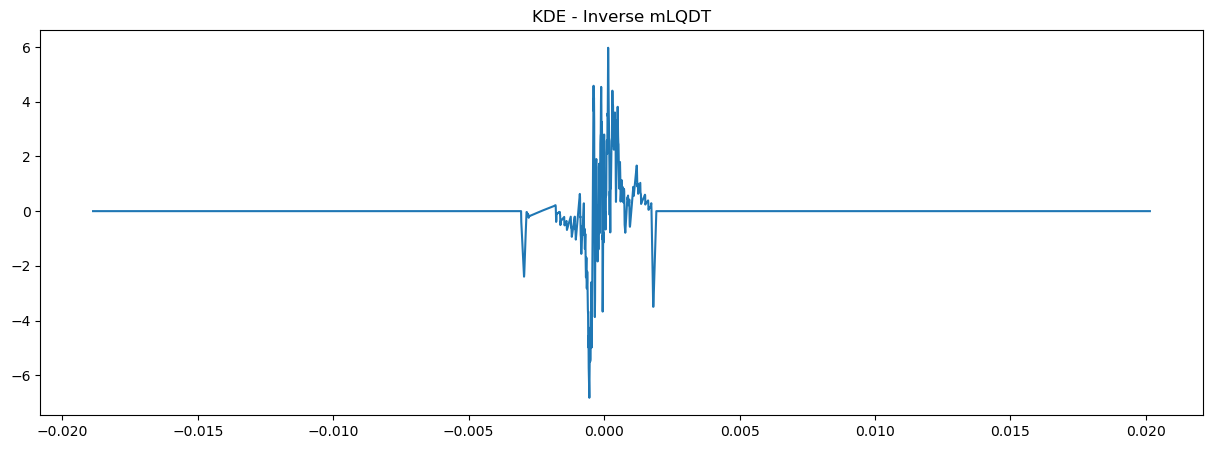

In [35]:
plt.figure(figsize=(15,5))
plt.plot(grid, f_col - f_hat_col)
plt.title("KDE - Inverse mLQDT")
plt.show()